In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [4]:
# Load dataset
df = pd.read_csv(r"D:\Loan_Approval_Request\data\raw\Loan Prediction.csv")

# Preview
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [5]:
print("Shape:", df.shape)
df.info()
df.describe(include="all")
df.isnull().sum()

Shape: (252000, 13)
<class 'pandas.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Id                 252000 non-null  int64
 1   Income             252000 non-null  int64
 2   Age                252000 non-null  int64
 3   Experience         252000 non-null  int64
 4   Married/Single     252000 non-null  str  
 5   House_Ownership    252000 non-null  str  
 6   Car_Ownership      252000 non-null  str  
 7   Profession         252000 non-null  str  
 8   CITY               252000 non-null  str  
 9   STATE              252000 non-null  str  
 10  CURRENT_JOB_YRS    252000 non-null  int64
 11  CURRENT_HOUSE_YRS  252000 non-null  int64
 12  Risk_Flag          252000 non-null  int64
dtypes: int64(7), str(6)
memory usage: 36.0 MB


Id                   0
Income               0
Age                  0
Experience           0
Married/Single       0
House_Ownership      0
Car_Ownership        0
Profession           0
CITY                 0
STATE                0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64

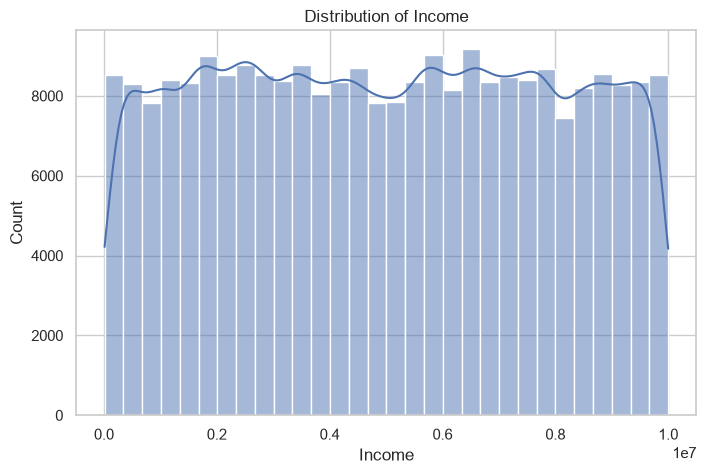

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Income"],
    bins=30,
    kde=True
)

plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()


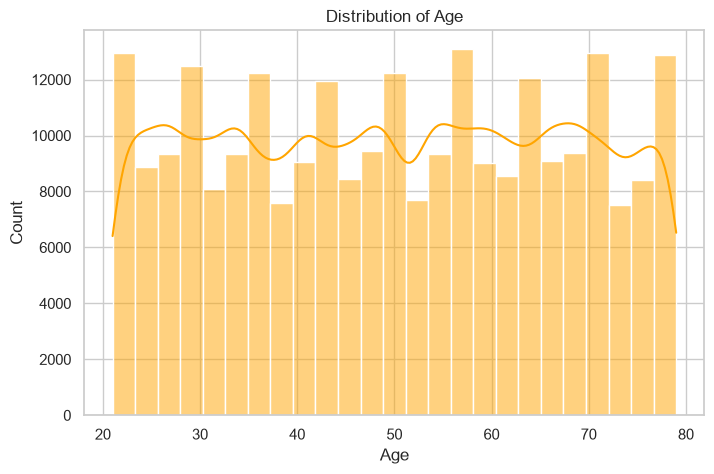

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=25,
    kde=True,
    color="orange"
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

In [9]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.head()

,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,3,13,0
1,2,7574516,40,10,9,13,0
2,3,3991815,66,4,4,10,0
3,4,6256451,41,2,2,12,1
4,5,5768871,47,11,3,14,1


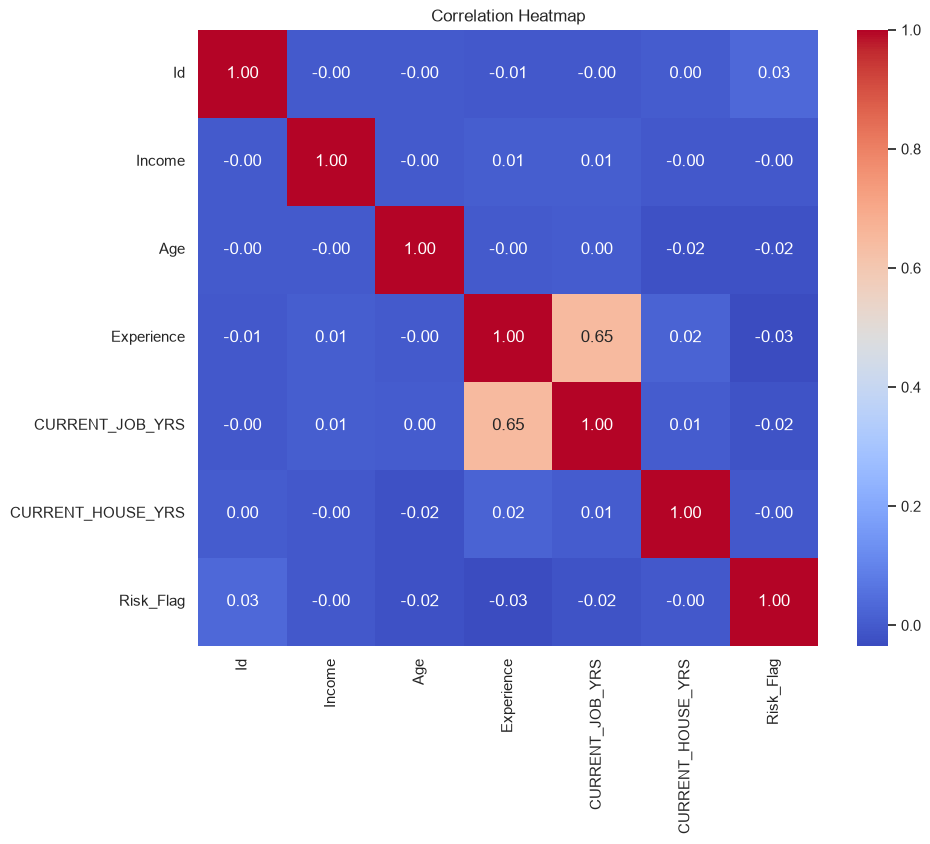

In [10]:
plt.figure(figsize=(10,8))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [11]:
print("Unique cities:", df["CITY"].nunique())
print("Unique professions:", df["Profession"].nunique())

Unique cities: 317
Unique professions: 51


In [12]:
df["CITY"].value_counts().head(10)

CITY
Vijayanagaram    1259
Bhopal           1208
Bulandshahr      1185
Saharsa[29]      1180
Vijayawada       1172
Srinagar         1136
Indore           1130
Hajipur[31]      1098
New_Delhi        1098
Satara           1096
Name: count, dtype: int64

In [13]:
df["Profession"].value_counts().head(10)

Profession
Physician                     5957
Statistician                  5806
Web_designer                  5397
Psychologist                  5390
Computer_hardware_engineer    5372
Drafter                       5359
Magistrate                    5357
Fashion_Designer              5304
Air_traffic_controller        5281
Comedian                      5259
Name: count, dtype: int64

# 📊 Notebook 01: Exploratory Data Analysis (EDA)
**Project**: End-to-End Loan Approval Prediction System  
**Objective**: Analyze feature distributions, study correlations, profile high-cardinality categorical fields, and document core underwriting constraints before pipeline development.


In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styling parameters for clean document look
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the core dataset
DATA_PATH = "../data/raw/Loan Prediction.csv"
if not os.path.exists(DATA_PATH):
    # Fallback for root-level notebook executions
    DATA_PATH = "data/raw/Loan Prediction.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset Shape: {df.shape}")
df.head()



Dataset Shape: (252000, 13)


,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [10]:
print("=== Structural Schema Summary ===")
print(df.info())

print("\n=== Missing Values Assessment ===")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "No missing values detected.")

print("\n=== Duplicate Records Count ===")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

print("\n=== Class Balance Profiling (Target Field) ===")
print(df['Risk_Flag'].value_counts(normalize=True))


=== Structural Schema Summary ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB
None

=== Missing Values Assessment ===
No missing values detected.

=== Duplicate R

### 📝 Initial Data Profiling Observations:
* **Class Imbalance**: The target feature `Risk_Flag` shows a clear class imbalance (~87% low risk vs ~13% high risk). This means we must use stratified data splits and optimization metrics like F1-Score instead of simple accuracy during modeling.
* **Structural Key**: The column `Id` is a sequential index with zero predictive value and will be safely dropped before training.


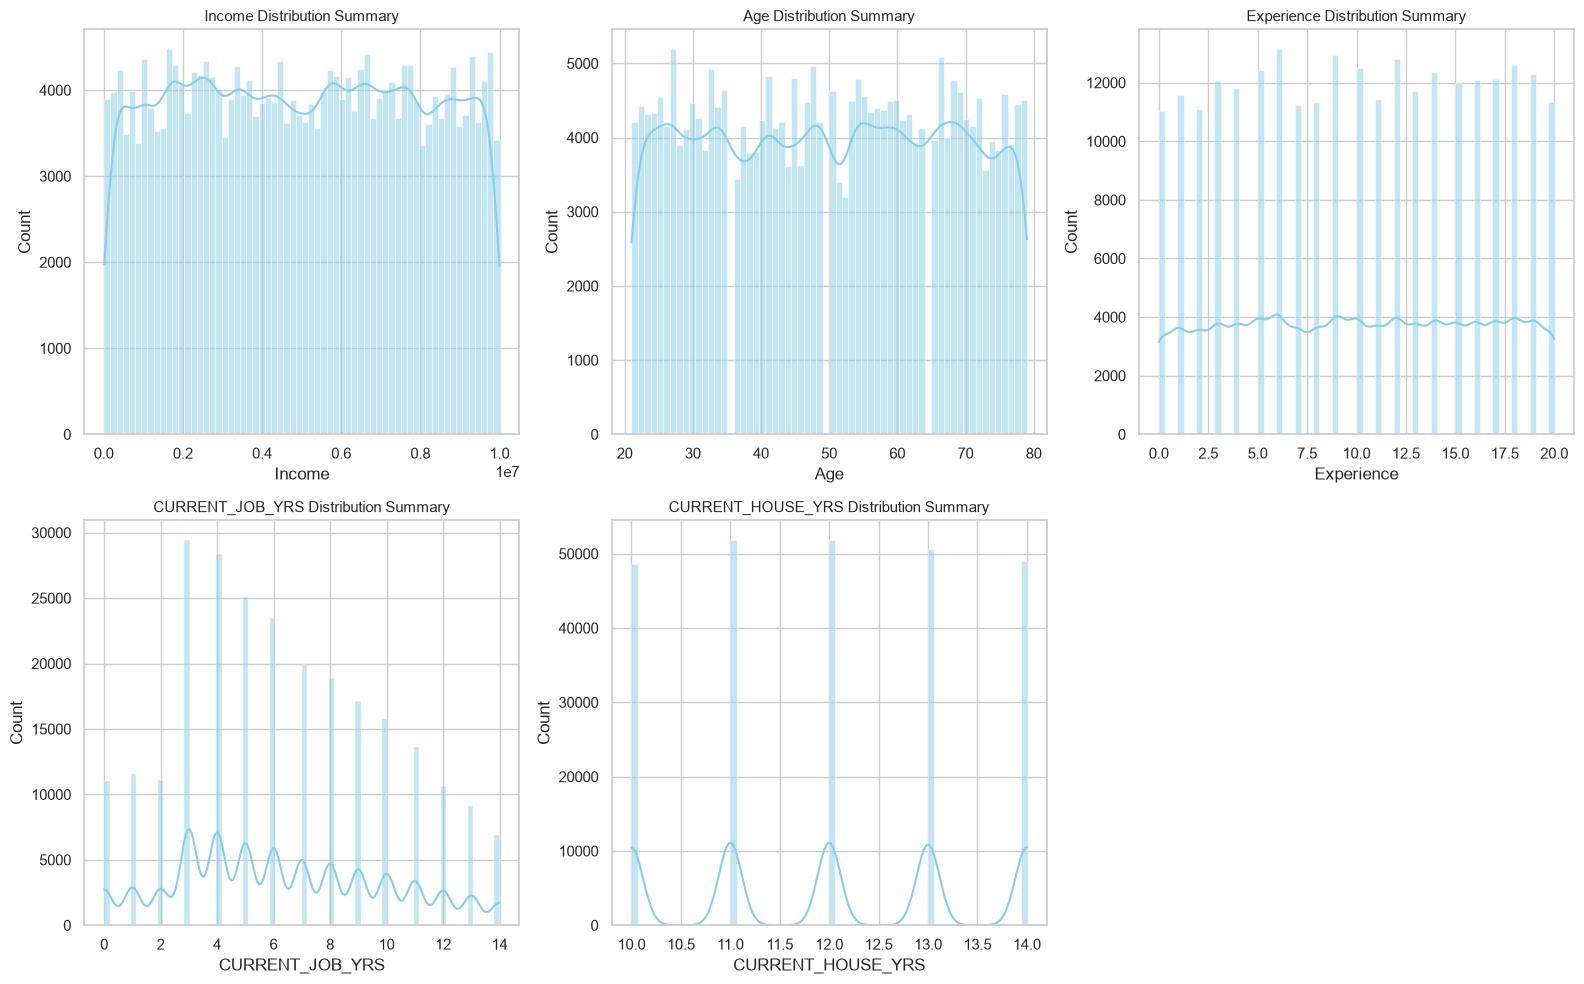

=== Descriptive Statistics Summary ===


,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS
count,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000
mean,4.997117e+06,49.954071,10.084437,6.333877,11.997794
std,2.878311e+06,17.063855,6.002590,3.647053,1.399037
min,1.031000e+04,21.000000,0.000000,0.000000,10.000000
25%,2.503015e+06,35.000000,5.000000,3.000000,11.000000
50%,5.000694e+06,50.000000,10.000000,6.000000,12.000000
75%,7.477502e+06,65.000000,15.000000,9.000000,13.000000
max,9.999938e+06,79.000000,20.000000,14.000000,14.000000


In [12]:
numeric_features = ['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[idx], color="skyblue")
    axes[idx].set_title(f'{col} Distribution Summary', fontsize=11)

# Remove the unused 6th subplot axis window
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

print("=== Descriptive Statistics Summary ===")
df[numeric_features].describe()



### 📝 Distribution Observations:
* **Income Profile**: `Income` shows an approximately uniform distribution across its range, indicating a highly varied demographic without a traditional bell-curve mid-income cluster.
* **Stability Indicators**: Both `CURRENT_JOB_YRS` and `CURRENT_HOUSE_YRS` show high frequencies at lower bounds, pointing to a segment of mobile or early-career applicants who may carry distinct risk profiles.


=== Unique Label Cardinality Counts ===
Feature 'Married/Single': 2 unique categories
Feature 'House_Ownership': 3 unique categories
Feature 'Car_Ownership': 2 unique categories
Feature 'Profession': 51 unique categories
Feature 'CITY': 317 unique categories
Feature 'STATE': 29 unique categories


C:\Users\Administrator\AppData\Local\Temp\ipykernel_5332\2917924967.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Profession'], order=df['Profession'].value_counts().index[:10], ax=ax1, palette="viridis")
C:\Users\Administrator\AppData\Local\Temp\ipykernel_5332\2917924967.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['STATE'], order=df['STATE'].value_counts().index[:10], ax=ax2, palette="magma")


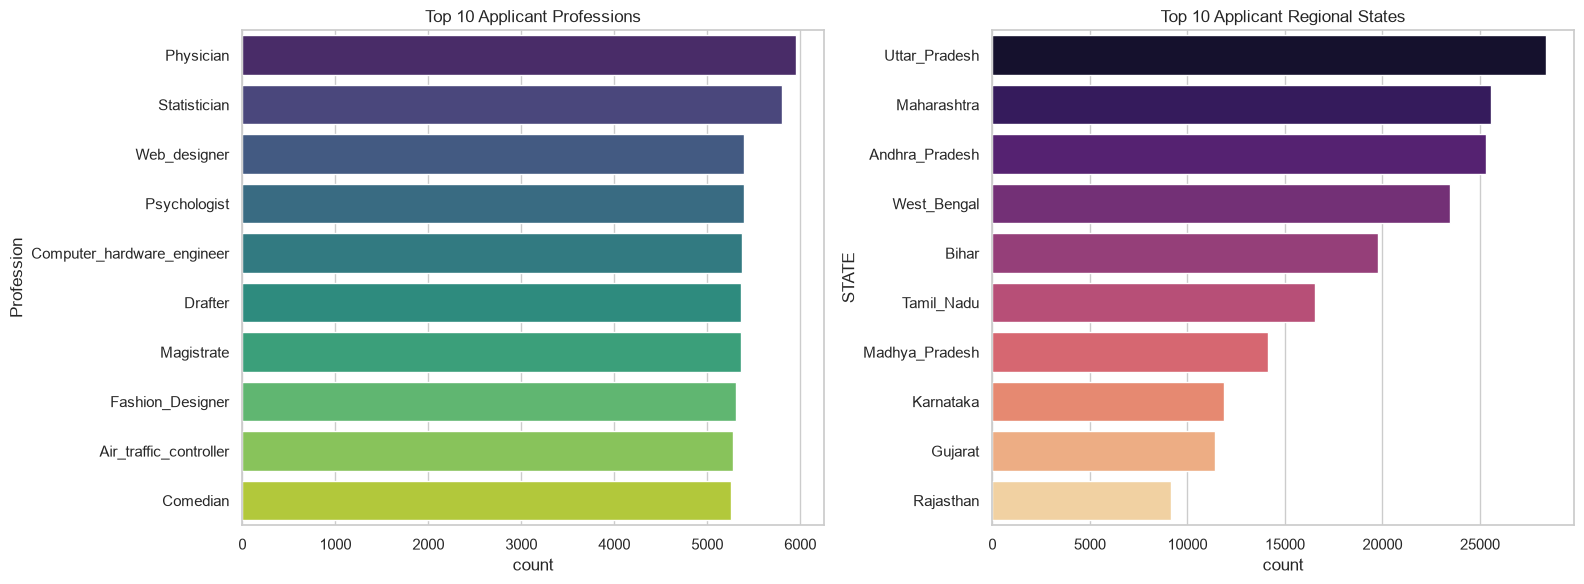

In [13]:
categorical_features = ['Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE']

print("=== Unique Label Cardinality Counts ===")
for col in categorical_features:
    print(f"Feature '{col}': {df[col].nunique()} unique categories")

# Plot top categories for high cardinality fields
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(y=df['Profession'], order=df['Profession'].value_counts().index[:10], ax=ax1, palette="viridis")
ax1.set_title("Top 10 Applicant Professions")

sns.countplot(y=df['STATE'], order=df['STATE'].value_counts().index[:10], ax=ax2, palette="magma")
ax2.set_title("Top 10 Applicant Regional States")

plt.tight_layout()
plt.show()


### 📝 Categorical Profiling Observations:
* **High-Cardinality Complexity**: `CITY` (~317 labels) and `Profession` (~51 labels) have exceptionally high cardinality. Standard One-Hot Encoding would expand the dataset's width exponentially. This confirms why we need sparse matrix processing arrays (`sparse_output=True`) in the pipeline to avoid running out of memory.


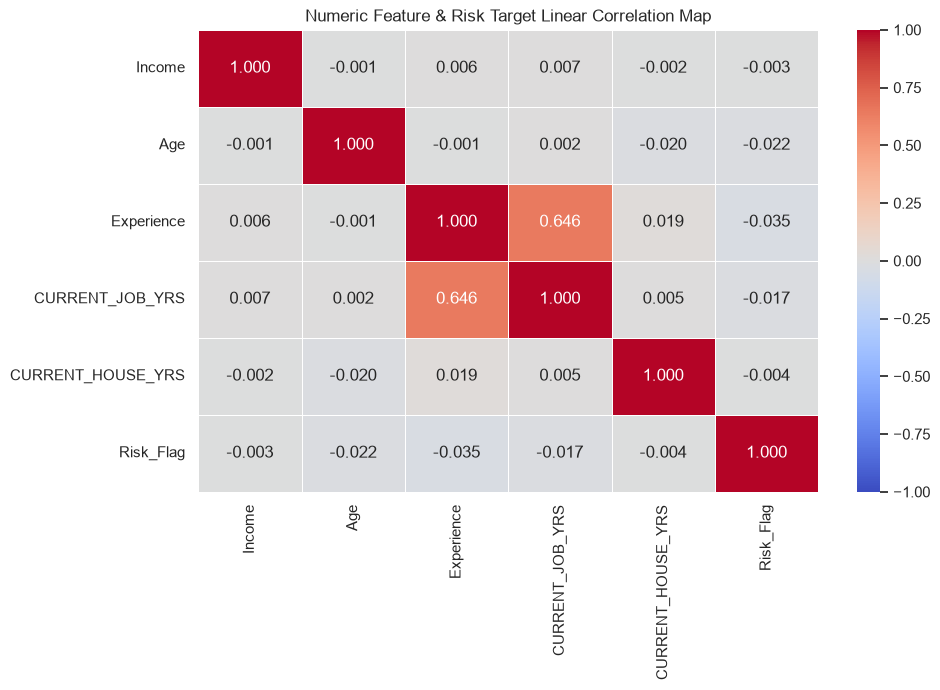

In [14]:
# Select numeric fields including the target label
analysis_cols = numeric_features + ['Risk_Flag']
correlation_matrix = df[analysis_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Numeric Feature & Risk Target Linear Correlation Map")
plt.show()

### 📝 Correlation Analysis Findings:
* **Weak Linear Signals**: No individual numeric attribute shows a strong linear correlation with `Risk_Flag`. This reveals that individual features cannot accurately isolate defaults on their own. We will need non-linear tree-based models (like Random Forest and XGBoost) to capture complex, multi-variable interactions.


C:\Users\Administrator\AppData\Local\Temp\ipykernel_5332\761902185.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='House_Ownership', y='Risk_Flag', data=df, ax=ax1, errorbar=None, palette="muted")
C:\Users\Administrator\AppData\Local\Temp\ipykernel_5332\761902185.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Flag', y='Experience', data=df, ax=ax2, palette="pastel")
C:\Users\Administrator\AppData\Local\Temp\ipykernel_5332\761902185.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_xticklabels(["Approved (Low Risk)", "Defaulted (High Risk)"])

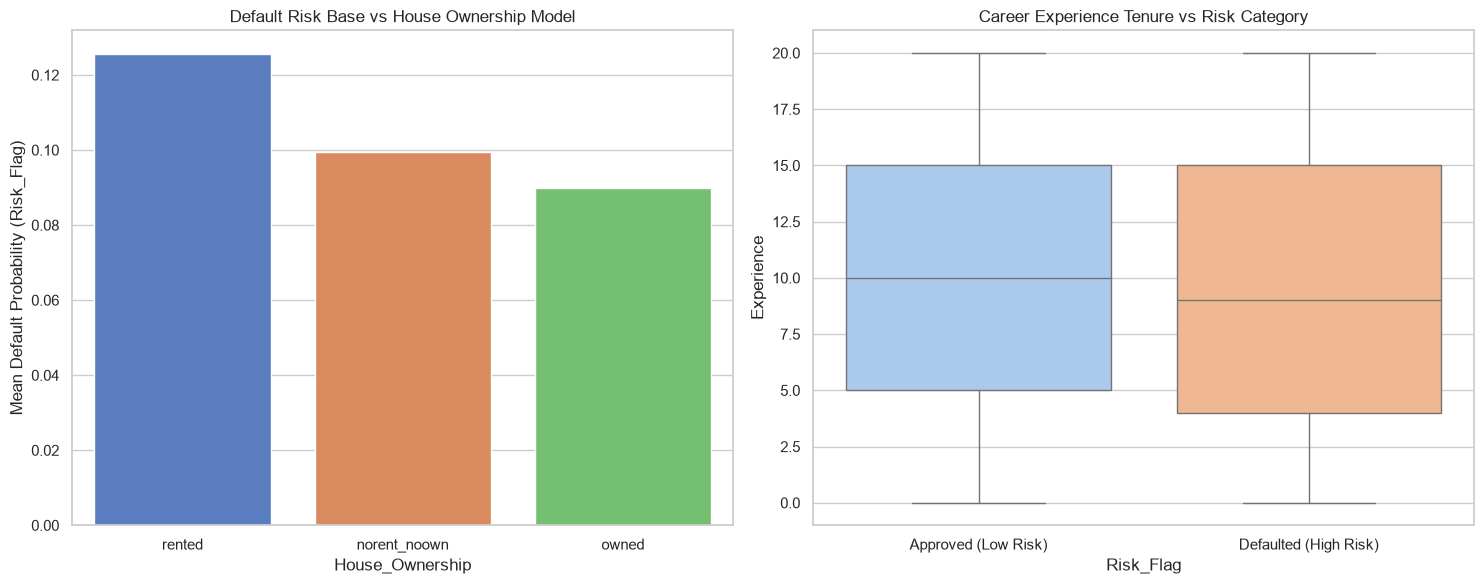

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Risk breakdown relative to property holding assets
sns.barplot(x='House_Ownership', y='Risk_Flag', data=df, ax=ax1, errorbar=None, palette="muted")
ax1.set_title("Default Risk Base vs House Ownership Model")
ax1.set_ylabel("Mean Default Probability (Risk_Flag)")

# Risk distribution across career experience duration thresholds
sns.boxplot(x='Risk_Flag', y='Experience', data=df, ax=ax2, palette="pastel")
ax2.set_title("Career Experience Tenure vs Risk Category")
ax2.set_xticklabels(["Approved (Low Risk)", "Defaulted (High Risk)"])

plt.tight_layout()
plt.show()


### 🏁 Concluding EDA Insights for Pipeline Implementation:
1. **Feature Engineering Focus**: Since single raw fields show weak correlation signals, we must engineer composite tracking features. These will include metrics like `career_stability_ratio` (`CURRENT_JOB_YRS` / `Experience`) and asset depth indicators.
2. **Algorithmic Plan**: Given the non-linear relationship patterns and high-cardinality text entries, tree ensemble variants (Random Forest and XGBoost) will serve as our primary champion model candidates.
